## Data Cleaning
The raw dataset contains 19,382 rows and 12 columns.
298 rows had missing engagement data and were dropped,
leaving 19,084 clean rows for analysis.
A total_engagement column was created by summing likes, comments, and shares.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tiktok_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (19382, 12)

Columns: ['#', 'claim_status', 'video_id', 'video_duration_sec', 'video_transcription_text', 'verified_status', 'author_ban_status', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']

First 5 rows:


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic stats:")
df.describe()

Missing values:
#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

Data types:
#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Basic stats:


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [4]:
df_clean = df.dropna()

print("Rows before:", len(df))
print("Rows after:", len(df_clean))
print("Rows dropped:", len(df) - len(df_clean))

Rows before: 19382
Rows after: 19084
Rows dropped: 298


In [5]:
df_clean = df_clean.copy()

df_clean['total_engagement'] = (
    df_clean['video_like_count'] +
    df_clean['video_comment_count'] +
    df_clean['video_share_count']
)

df_clean['engagement_rate'] = (
    df_clean['total_engagement'] / df_clean['video_view_count']
)

print("New columns added successfully")
df_clean[['video_view_count', 'total_engagement', 'engagement_rate']].head()

New columns added successfully


,video_view_count,total_engagement,engagement_rate
0,343296.0,19666.0,0.057286
1,140877.0,97073.0,0.689062
2,902185.0,100877.0,0.111814
3,437506.0,275350.0,0.629363
4,56167.0,39249.0,0.698791


## Question 1: Do claim videos or opinion videos get more engagement?

Claim videos and opinion videos represent fundamentally different types of content on TikTok.
This analysis explores whether these two content types show different engagement behaviour,
specifically in terms of views, likes, shares, and overall engagement rate.

In [6]:
claim_analysis = df_clean.groupby('claim_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_likes=('video_like_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_comments=('video_comment_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(claim_analysis)

              avg_views  avg_likes  avg_shares  avg_comments  \
claim_status                                                   
claim         501029.45  166373.33    33026.42        691.16   
opinion         4956.43    1092.73      217.15          2.70   

              avg_engagement_rate  video_count  
claim_status                                    
claim                        0.40         9608  
opinion                      0.26         9476  


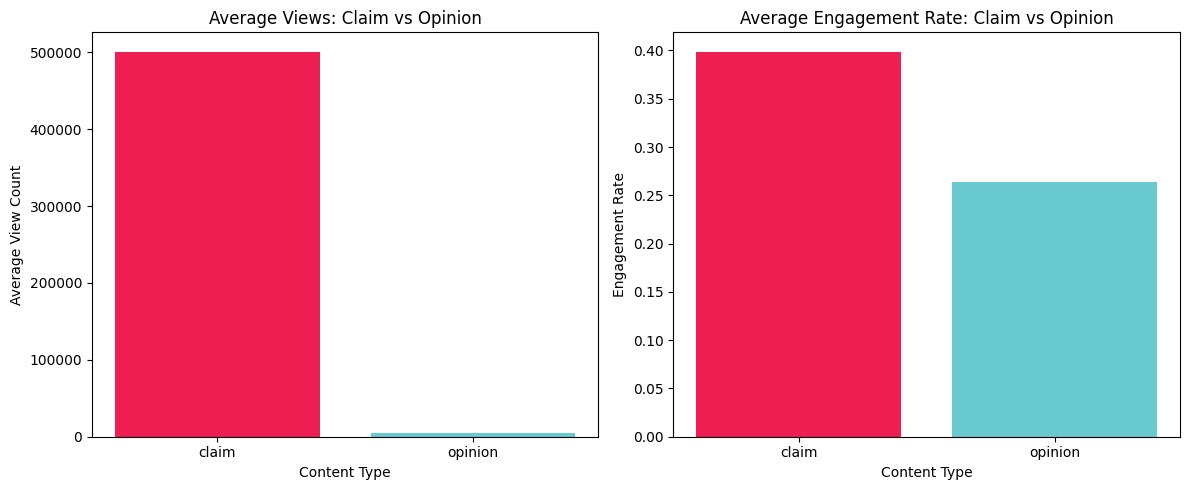

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ['claim', 'opinion']
avg_views = [
    df_clean[df_clean['claim_status']=='claim']['video_view_count'].mean(),
    df_clean[df_clean['claim_status']=='opinion']['video_view_count'].mean()
]

axes[0].bar(categories, avg_views, color=['#EE1D52', '#69C9D0'])
axes[0].set_title('Average Views: Claim vs Opinion')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Content Type')

avg_er = [
    df_clean[df_clean['claim_status']=='claim']['engagement_rate'].mean(),
    df_clean[df_clean['claim_status']=='opinion']['engagement_rate'].mean()
]

axes[1].bar(categories, avg_er, color=['#EE1D52', '#69C9D0'])
axes[1].set_title('Average Engagement Rate: Claim vs Opinion')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Content Type')

plt.tight_layout()
plt.savefig('claim_vs_opinion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Claim videos receive approximately 100x more views than opinion videos on average
(501,029 vs 4,956), with consistently higher engagement across all metrics.
This suggests claim-based content spreads significantly further on the platform,
raising questions about whether algorithmic amplification plays a role.

## Question 2: Does author verification status affect how far videos spread?

Verified accounts carry an implicit trust signal on TikTok.
This analysis explores whether videos from verified authors reach wider audiences
and generate more engagement compared to unverified authors.

In [8]:
verified_analysis = df_clean.groupby('verified_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(verified_analysis)

                 avg_views  avg_shares  avg_engagement_rate  video_count
verified_status                                                         
not verified     265663.79    17415.89                 0.33        17884
verified          91439.16     6591.45                 0.29         1200


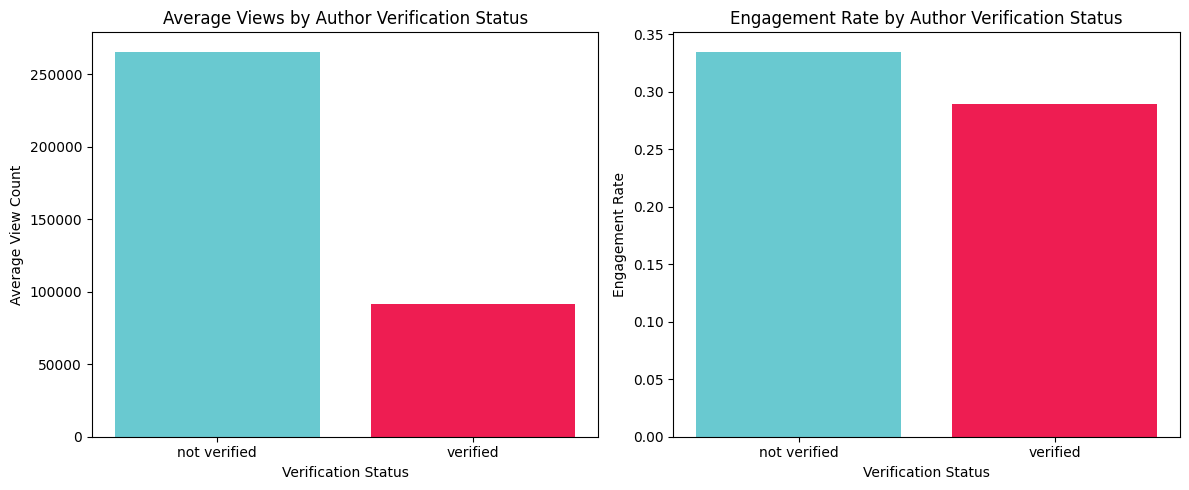

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

verified_groups = df_clean.groupby('verified_status')['video_view_count'].mean()
axes[0].bar(verified_groups.index, verified_groups.values, color=['#69C9D0', '#EE1D52'])
axes[0].set_title('Average Views by Author Verification Status')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Verification Status')

verified_er = df_clean.groupby('verified_status')['engagement_rate'].mean()
axes[1].bar(verified_er.index, verified_er.values, color=['#69C9D0', '#EE1D52'])
axes[1].set_title('Engagement Rate by Author Verification Status')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Verification Status')

plt.tight_layout()
plt.savefig('verified_vs_unverified.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Counterintuitively, unverified authors outperform verified authors in average views
(265,663 vs 91,439) and shares. This is unexpected as verification is generally
associated with credibility and reach.

One likely explanation: unverified authors account for 94% of videos in this dataset
(17,884 vs 1,200 videos), and this group may include authors who were later banned
or placed under scrutiny, authors who potentially accumulated high views through
misinformation or manipulation before being actioned by TikTok's trust and safety team.

This raises a key question: are high-engagement videos more likely to come from
banned accounts? This is examined in Question 3.

## Question 3: Do banned accounts show different engagement patterns?

The previous analysis raised a question: could banned or flagged accounts be
driving the unexpectedly high engagement seen among unverified authors?

This analysis examines whether author ban status correlates with engagement levels,
which could help identify at-risk accounts earlier in the content lifecycle.

In [11]:
ban_analysis = df_clean.groupby('author_ban_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_likes=('video_like_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(ban_analysis)

                   avg_views  avg_likes  avg_shares  avg_engagement_rate  \
author_ban_status                                                          
active             215927.04   71036.53    14111.47                 0.32   
banned             445845.44  153017.24    29998.94                 0.39   
under review       392204.84  128718.05    25774.70                 0.37   

                   video_count  
author_ban_status               
active                   15383  
banned                    1635  
under review              2066  


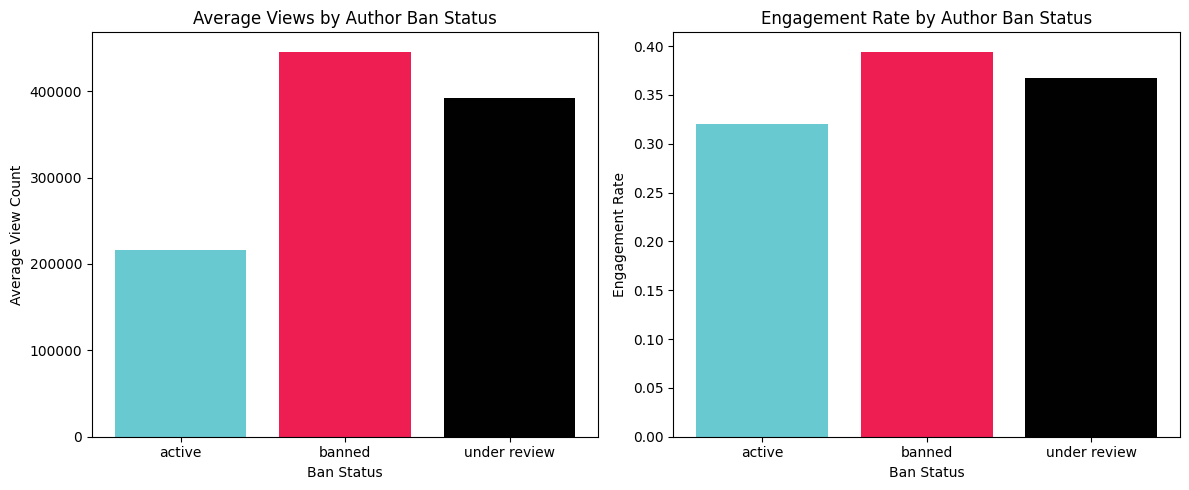

Chart saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ban_views = df_clean.groupby('author_ban_status')['video_view_count'].mean()
axes[0].bar(ban_views.index, ban_views.values, color=['#69C9D0', '#EE1D52', '#010101'])
axes[0].set_title('Average Views by Author Ban Status')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Ban Status')

ban_er = df_clean.groupby('author_ban_status')['engagement_rate'].mean()
axes[1].bar(ban_er.index, ban_er.values, color=['#69C9D0', '#EE1D52', '#010101'])
axes[1].set_title('Engagement Rate by Author Ban Status')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Ban Status')

plt.tight_layout()
plt.savefig('ban_status_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Banned accounts generated more than double the average views of active accounts
(445,845 vs 215,927), with accounts under review sitting in between (392,204).
Engagement rate follows the same pattern: banned accounts score highest at 0.39, compared to 0.32 for active accounts.

This aligns with the hypothesis from the previous analysis. Videos from accounts
that were eventually banned were already attracting significantly more views and
interactions, suggesting that engagement velocity could serve as an early indicator
for content review prioritisation.